# <h1 style="color:#6f42c1;">🍷 Wine Quality Prediction</h1>

##  Objective
The goal of this project is to build a machine learning model that predicts wine quality based on physicochemical properties.

##  Key Questions
- Which features influence wine quality the most?
- Can we accurately classify good vs bad wine?
- Which model performs best?

##  Dataset
The dataset contains chemical properties of red wine samples such as acidity, alcohol, pH, and sulphates.

## Importing Libraries
We import the necessary libraries for data manipulation, visualization, and modeling.

In [152]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_style("whitegrid")


<h2 style="color:#17a2b8;">📂 Loading the Dataset</h2>
We inspect the structure, data types, and basic statistics of the dataset.

In [153]:
df = pd.read_csv("data/winequalityN.csv")
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


<h2 style="color:#17a2b8;">🔍 Understanding the Dataset</h2>

We inspect:
<ul>
<li>Data types</li>
<li>Number of entries</li>
<li>Statistical summary</li>
</ul>

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [155]:
df.shape

(6497, 13)

In [156]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [157]:
df.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

<h2 style="color:#dc3545;">🧹 Data Cleaning</h2>

We check for:
<ul>
<li>Missing values</li>
<li>Duplicate rows</li>
</ul>

In [158]:

# Fill missing values using median for all numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values AFTER cleaning:")
print(df.isnull().sum())

Missing values AFTER cleaning:
type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [159]:
df_clean = df.drop_duplicates().reset_index(drop=True)
df_clean.shape

(5329, 13)

In [160]:
print("Missing values:\n", df_clean.isnull().sum())
print("\nDuplicates:", df_clean.duplicated().sum())
print("\nFinal shape:", df_clean.shape)

Missing values:
 type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicates: 0

Final shape: (5329, 13)


# Distribution of target variable 

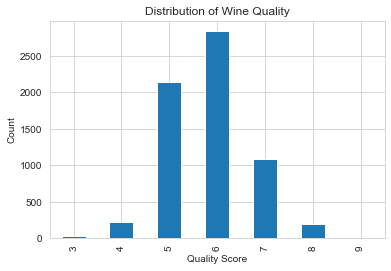

In [161]:
import matplotlib.pyplot as plt

# Distribution of wine quality scores
df['quality'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

Insight:

This shows whether the dataset is balanced or skewed toward certain quality ratings.

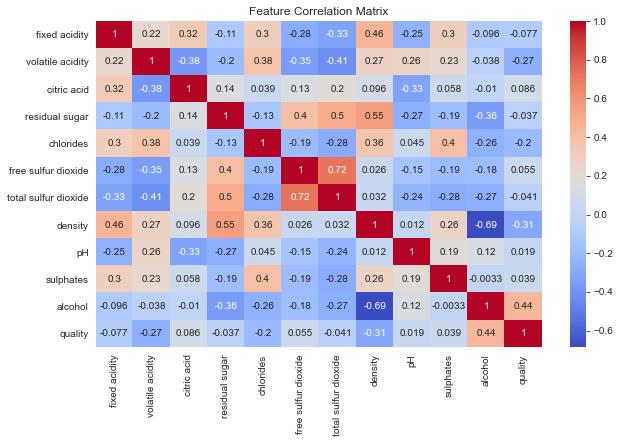

In [162]:
#Correlation Analysis
import seaborn as sns

# Correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

Insight:

This tells us which features are strongly positive or negative predictors.

# Data Preparation

In [163]:
#Define Features and Target
X = df.drop('quality', axis=1)
y = df['quality']

In [164]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [165]:
#model building
# import models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [168]:
# checking non numeric columns
X_train.dtypes

type                     object
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
dtype: object

In [169]:
# identifying categorical column
categorical_cols = X_train.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['type'], dtype='object')


In [170]:
# label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [171]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling successful")

Scaling successful


In [172]:
# linearregression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate
print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression
MSE: 0.4711911092308267
R2 Score: 0.3408065203047843


In [173]:
# ridge regression
from sklearn.linear_model import Ridge

# Initialize model
ridge_model = Ridge(alpha=1.0)

# Train
ridge_model.fit(X_train_scaled, y_train)

# Predict
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Evaluate
print("Ridge Regression")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

Ridge Regression
MSE: 0.47120785334302495
R2 Score: 0.3407830953942371


In [174]:
# comparing the models
print("Model Comparison")
print("------------------")
print("Linear R2:", r2_score(y_test, y_pred_lr))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Model Comparison
------------------
Linear R2: 0.3408065203047843
Ridge R2: 0.3407830953942371


In [175]:
# final model selection
best_model = "Linear Regression" if r2_score(y_test, y_pred_lr) > r2_score(y_test, y_pred_ridge) else "Ridge Regression"

print("Best Model:", best_model)

Best Model: Linear Regression
